In [1]:
# Color comparison between real and fake images.

import os
import numpy as np
from PIL import Image

cleaned_path = "merged_dataset"
real_dir = os.path.join(cleaned_path, "real")
fake_dir = os.path.join(cleaned_path, "fake")

def compute_color_stats(folder):
    means = []
    stds = []

    files = [f for f in os.listdir(folder) if f.lower().endswith(".jpg")]

    for i, fname in enumerate(files):
        if i % 10000 == 0:
            print(f"Processed {i} images in {folder}...")

        img = Image.open(os.path.join(folder, fname)).convert("RGB")
        arr = np.array(img) / 255.0  # normalize to [0,1]

        means.append(arr.mean(axis=(0,1)))
        stds.append(arr.std(axis=(0,1)))

    means = np.array(means)
    stds = np.array(stds)

    return means.mean(axis=0), stds.mean(axis=0)

real_mean, real_std = compute_color_stats(real_dir)
fake_mean, fake_std = compute_color_stats(fake_dir)

print("\n=== REAL ===")
print("Mean RGB:", real_mean)
print("Std RGB:", real_std)

print("\n=== FAKE ===")
print("Mean RGB:", fake_mean)
print("Std RGB:", fake_std)

Processed 0 images in merged_dataset\real...
Processed 10000 images in merged_dataset\real...
Processed 20000 images in merged_dataset\real...
Processed 30000 images in merged_dataset\real...
Processed 40000 images in merged_dataset\real...
Processed 50000 images in merged_dataset\real...
Processed 60000 images in merged_dataset\real...
Processed 70000 images in merged_dataset\real...
Processed 80000 images in merged_dataset\real...
Processed 90000 images in merged_dataset\real...
Processed 100000 images in merged_dataset\real...
Processed 110000 images in merged_dataset\real...
Processed 0 images in merged_dataset\fake...
Processed 10000 images in merged_dataset\fake...
Processed 20000 images in merged_dataset\fake...
Processed 30000 images in merged_dataset\fake...
Processed 40000 images in merged_dataset\fake...
Processed 50000 images in merged_dataset\fake...
Processed 60000 images in merged_dataset\fake...
Processed 70000 images in merged_dataset\fake...
Processed 80000 images in 

Processing merged_dataset/fake: 100%|██████████| 236389/236389 [24:17<00:00, 162.18it/s]


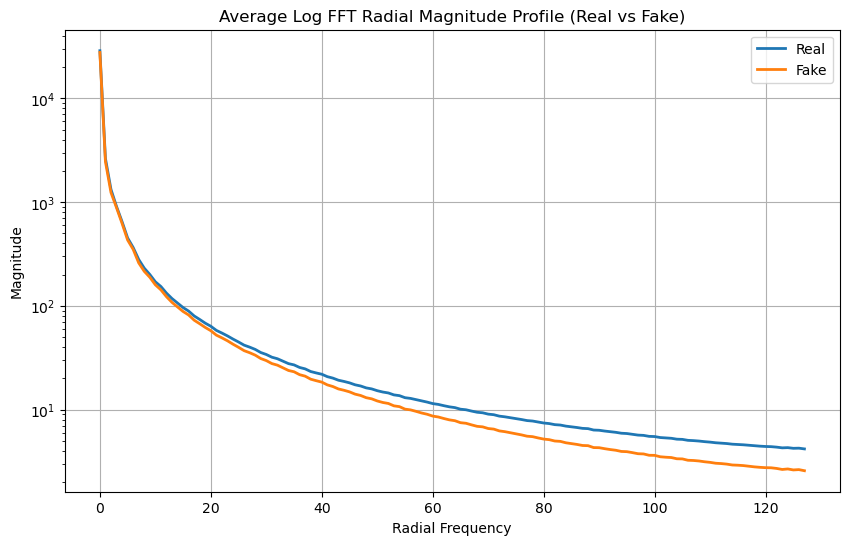

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
real_dir = "merged_dataset/real"
fake_dir = "merged_dataset/fake"

def fft_magnitude(img):
    """Compute centered FFT magnitude for a grayscale image."""
    img_gray = np.array(img.convert("L"), dtype=np.float32) / 255.0
    fft = np.fft.fft2(img_gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)
    return magnitude

def radial_profile(mag):
    """Compute radial average of FFT magnitude."""
    h, w = mag.shape
    cy, cx = h // 2, w // 2

    y, x = np.indices((h, w))
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(np.int32)

    max_r = min(cx, cy)
    radial_mean = np.bincount(r.ravel(), mag.ravel()) / np.bincount(r.ravel())
    return radial_mean[:max_r]

def process_folder(folder):
    profiles = []
    files = os.listdir(folder)

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path)
        except:
            continue

        mag = fft_magnitude(img)
        prof = radial_profile(mag)
        profiles.append(prof)

    # Pad to same length
    max_len = max(len(p) for p in profiles)
    padded = np.array([np.pad(p, (0, max_len - len(p)), mode='edge') for p in profiles])

    return padded

# Process real and fake
real_profiles = process_folder(real_dir)
fake_profiles = process_folder(fake_dir)

# Compute class averages
real_mean = real_profiles.mean(axis=0)
fake_mean = fake_profiles.mean(axis=0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(real_mean, label="Real", linewidth=2)
plt.plot(fake_mean, label="Fake", linewidth=2)
plt.title("Average Log FFT Radial Magnitude Profile (Real vs Fake)")
plt.xlabel("Radial Frequency")
plt.ylabel("Magnitude")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

Processing merged_dataset/fake: 100%|██████████| 236389/236389 [1:20:38<00:00, 48.86it/s]


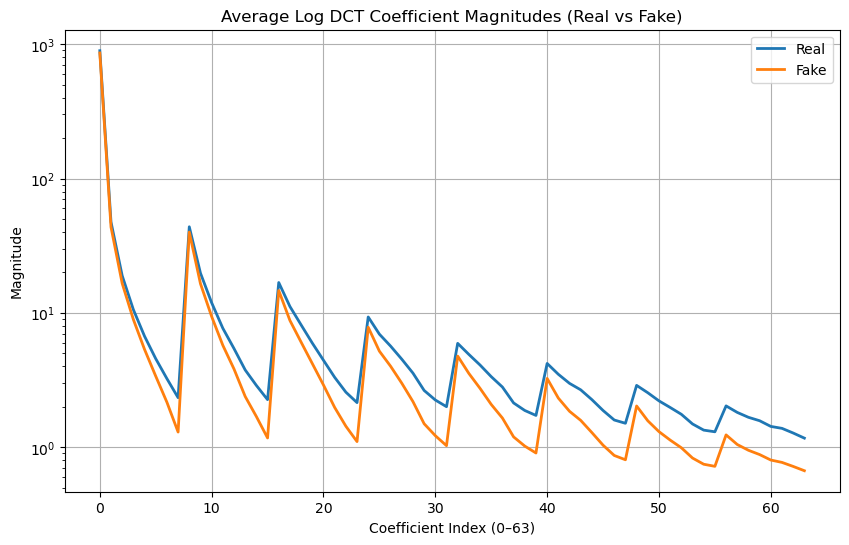

In [3]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.fftpack import dct

real_dir = "merged_dataset/real"
fake_dir = "merged_dataset/fake"

def block_dct(img, block=8):
    """Compute 8×8 block DCT magnitudes for a grayscale image."""
    arr = np.array(img.convert("L"), dtype=np.float32)
    h, w = arr.shape

    # ensure divisible by block size
    h = h - (h % block)
    w = w - (w % block)
    arr = arr[:h, :w]

    coeffs = []

    for i in range(0, h, block):
        for j in range(0, w, block):
            patch = arr[i:i+block, j:j+block]
            d = dct(dct(patch.T, norm='ortho').T, norm='ortho')
            coeffs.append(np.abs(d))

    coeffs = np.stack(coeffs)  # shape: (num_blocks, 8, 8)
    return coeffs

def process_folder(folder):
    all_coeffs = []

    for fname in tqdm(os.listdir(folder), desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path)
        except:
            continue

        c = block_dct(img)
        all_coeffs.append(c.mean(axis=0))  # average over blocks

    return np.stack(all_coeffs)  # shape: (num_images, 8, 8)

real_dct = process_folder(real_dir)
fake_dct = process_folder(fake_dir)

# average over images
real_mean = real_dct.mean(axis=0).flatten()
fake_mean = fake_dct.mean(axis=0).flatten()

plt.figure(figsize=(10,6))
plt.plot(real_mean, label="Real", linewidth=2)
plt.plot(fake_mean, label="Fake", linewidth=2)
plt.title("Average Log DCT Coefficient Magnitudes (Real vs Fake)")
plt.xlabel("Coefficient Index (0–63)")
plt.ylabel("Magnitude")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

Processing merged_dataset/fake: 100%|██████████| 236389/236389 [27:16<00:00, 144.41it/s]


Real mean: 6.3528304
Fake mean: 4.9292984


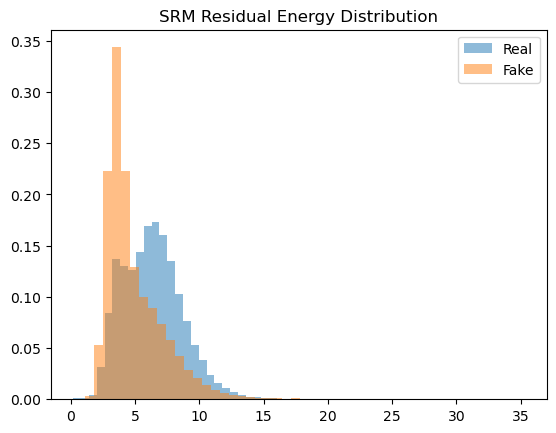

In [4]:
import os
import numpy as np
from PIL import Image
from scipy.signal import convolve2d
from tqdm import tqdm

# --- SRM-Lite high-pass filters ---
SRM_FILTERS = [
    np.array([[0, 0, 0],
              [0, 1, -1],
              [0, 0, 0]], dtype=np.float32),

    np.array([[0, 0, 0],
              [0, 1, 0],
              [0, -1, 0]], dtype=np.float32),

    np.array([[0, 0, 0],
              [0, 1, 0],
              [0, 0, -1]], dtype=np.float32)
]

def srm_residual_energy(img):
    """Compute SRM-lite residual energy for a grayscale image."""
    gray = np.array(img.convert("L"), dtype=np.float32)

    energies = []
    for f in SRM_FILTERS:
        r = convolve2d(gray, f, mode="same", boundary="symm")
        energies.append(np.mean(np.abs(r)))

    return np.mean(energies)

def process_folder(folder):
    values = []
    files = os.listdir(folder)

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path)
        except:
            continue

        val = srm_residual_energy(img)
        values.append(val)

    return np.array(values)

real_vals = process_folder("merged_dataset/real")
fake_vals = process_folder("merged_dataset/fake")

print("Real mean:", real_vals.mean())
print("Fake mean:", fake_vals.mean())

import matplotlib.pyplot as plt

plt.hist(real_vals, bins=50, alpha=0.5, label="Real", density=True)
plt.hist(fake_vals, bins=50, alpha=0.5, label="Fake", density=True)
plt.legend()
plt.title("SRM Residual Energy Distribution")
plt.show()